# Evaluation on a new dataset

This notebook tests the implementation on datasets that are **not** part of the original GEDI paper. This satisfies the lab requirement for external validation.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src.metrics import relative_deviation
from src.model import gedi_predict, run_clustering_suite
from src.utils import load_additional_dataset, set_random_seed

set_random_seed(42)

## 1. Load and inspect unseen datasets
We evaluate the pipeline on Wine and Digits, then verify the dataset size, feature dimension, and number of classes before running clustering.

In [2]:
datasets = {}
dataset_info_rows = []

for dataset_name in ['wine', 'digits']:
    X, y = load_additional_dataset(dataset_name)
    datasets[dataset_name] = {
        'X': X,
        'y': y,
        'n_clusters': int(np.unique(y).size),
    }
    dataset_info_rows.append({
        'Dataset': dataset_name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Classes': int(np.unique(y).size),
    })

dataset_info_df = pd.DataFrame(dataset_info_rows)
display(dataset_info_df)

,Dataset,Samples,Features,Classes
0,wine,178,13,3
1,digits,1797,64,10


## 2. Run clustering suite and confirm the reported metrics
The table below confirms that the notebook reports at least three metrics. In practice, the current pipeline returns six: `ACC`, `NMI`, `ARI`, `Silhouette`, `DBI`, and `CHI`.

In [6]:
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']
summary_tables = []

for dataset_name, payload in datasets.items():
    X = payload['X']
    y = payload['y']

    # Train all methods once and reuse the trained GEDI model
    table, gedi_model = run_clustering_suite(
        X, y, dataset_name=dataset_name, random_state=42, return_model=True
    )
    summary_tables.append(table.copy())

    # Reuse trained GEDI model for predictions (no second training pass)
    payload['gedi_pred'] = gedi_predict(gedi_model, X)

    # PCA for visualization only
    pca = PCA(n_components=2)
    payload['pca_2d'] = pca.fit_transform(X)
    payload['pca_var'] = pca.explained_variance_ratio_

results_df = pd.concat(summary_tables, ignore_index=True)
assert set(metric_columns).issubset(results_df.columns)

print('Reported metrics:', ', '.join(metric_columns))
display(results_df[['Dataset', 'Method', *metric_columns]])

Reported metrics: ACC, NMI, ARI, Silhouette, DBI, CHI


,Dataset,Method,ACC,NMI,ARI,Silhouette,DBI,CHI
0,wine,KMeans,0.966292,0.875894,0.897495,0.284859,1.389188,70.940008
1,wine,GaussianMixture,0.966292,0.875894,0.897495,0.284859,1.389188,70.940008
2,wine,Spectral,0.960674,0.860946,0.880400,0.282850,1.390741,70.041067
3,wine,Agglomerative,0.926966,0.786465,0.789933,0.277444,1.418592,67.647468
4,wine,GEDI,0.398876,0.000000,0.000000,NaN,NaN,NaN
5,digits,Spectral,0.781302,0.828247,0.706697,0.138423,1.961524,101.102947
6,digits,Agglomerative,0.745131,0.795587,0.664346,0.125325,1.967178,105.825164
7,digits,GaussianMixture,0.669449,0.690155,0.546745,0.117905,2.002885,102.577554
8,digits,KMeans,0.608792,0.631911,0.477962,0.142321,1.886166,114.671615
9,digits,GEDI,0.101836,0.000000,0.000000,NaN,NaN,NaN


## 3. Compare GEDI against the strongest baseline
We treat the best non-GEDI method on each dataset as the reference baseline, then compute the absolute and relative NMI gap of GEDI against that baseline.

In [7]:
baseline_df = results_df[results_df['Method'] != 'GEDI'].copy()
best_baseline_df = (
    baseline_df
    .sort_values(['Dataset', 'NMI', 'ACC'], ascending=[True, False, False])
    .groupby('Dataset', as_index=False)
    .first()
    .rename(columns={
        'Method': 'Best baseline',
        'NMI': 'Best baseline NMI',
        'ACC': 'Best baseline ACC',
        'ARI': 'Best baseline ARI',
    })
)

gedi_df = (
    results_df[results_df['Method'] == 'GEDI'][['Dataset', 'NMI', 'ACC', 'ARI']]
    .rename(columns={
        'NMI': 'GEDI NMI',
        'ACC': 'GEDI ACC',
        'ARI': 'GEDI ARI',
    })
    .reset_index(drop=True)
)

comparison_df = best_baseline_df[
    ['Dataset', 'Best baseline', 'Best baseline NMI', 'Best baseline ACC', 'Best baseline ARI']
].merge(gedi_df, on='Dataset', how='left')
comparison_df['Abs diff NMI'] = (
    comparison_df['GEDI NMI'] - comparison_df['Best baseline NMI']
).abs()
comparison_df['Rel diff % (GEDI vs best baseline)'] = [
    relative_deviation(gedi_nmi, baseline_nmi)
    for gedi_nmi, baseline_nmi in zip(
        comparison_df['GEDI NMI'],
        comparison_df['Best baseline NMI'],
    )
]
comparison_df = comparison_df.sort_values('Dataset').reset_index(drop=True)

display(comparison_df)

,Dataset,Best baseline,Best baseline NMI,Best baseline ACC,Best baseline ARI,GEDI NMI,GEDI ACC,GEDI ARI,Abs diff NMI,Rel diff % (GEDI vs best baseline)
0,digits,Spectral,0.828247,0.781302,0.706697,0.0,0.101836,0.0,0.828247,-100.0
1,wine,KMeans,0.875894,0.966292,0.897495,0.0,0.398876,0.0,0.875894,-100.0


## 4. PCA visualization: ground truth vs GEDI prediction
Because Wine and Digits are high-dimensional, we project each dataset to 2D with PCA and compare the ground-truth labels against the GEDI cluster assignments.

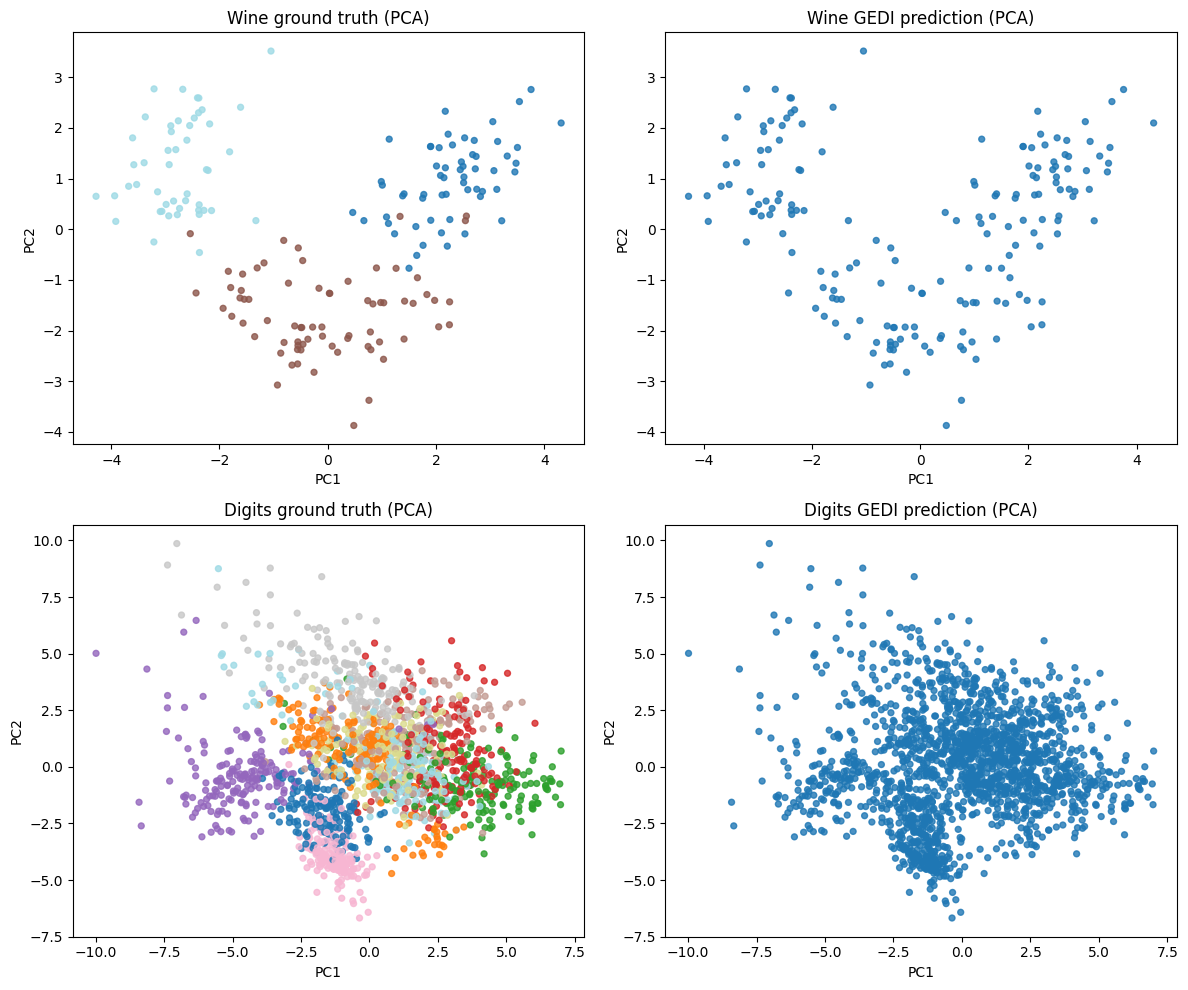

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, dataset_name in enumerate(['wine', 'digits']):
    payload = datasets[dataset_name]
    pca_2d = payload['pca_2d']
    y_true = payload['y']
    y_pred = payload['gedi_pred']

    axes[row, 0].scatter(
        pca_2d[:, 0],
        pca_2d[:, 1],
        c=y_true,
        cmap='tab20',
        s=18,
        alpha=0.8,
    )
    axes[row, 0].set_title(f'{dataset_name.title()} ground truth (PCA)')
    axes[row, 0].set_xlabel('PC1')
    axes[row, 0].set_ylabel('PC2')

    axes[row, 1].scatter(
        pca_2d[:, 0],
        pca_2d[:, 1],
        c=y_pred,
        cmap='tab20',
        s=18,
        alpha=0.8,
    )
    axes[row, 1].set_title(f'{dataset_name.title()} GEDI prediction (PCA)')
    axes[row, 1].set_xlabel('PC1')
    axes[row, 1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 5. Interpretation
- Notebook này dùng Wine (13 features) và Digits (64 features), nên GEDI không còn bị giới hạn ở dữ liệu 2D. Trong cả `run_clustering_suite` lẫn phần fit GEDI thủ công cho visualization, `in_features` được lấy trực tiếp từ `X.shape[1]`.
- Hãy đọc đồng thời bảng metrics và PCA plots: nếu GEDI tách được các cụm lớn nhưng vẫn lẫn ở biên, NMI/ARI thường sẽ giảm trước khi ACC giảm mạnh.
- So sánh bảng `GEDI vs best baseline` để xem GEDI đang tốt hơn hay kém hơn baseline mạnh nhất trên từng dataset. Giá trị `Rel diff %` dương nghĩa là GEDI tốt hơn baseline theo NMI; âm nghĩa là kém hơn.
- Nếu thứ hạng giữa Wine và Digits khác nhau, nguyên nhân hợp lý thường là số chiều lớn hơn, số lớp nhiều hơn, và mức chồng lấn cục bộ cao hơn trên Digits.